<a href="https://colab.research.google.com/github/abeerahateeq/Lead-Scoring-Model/blob/main/Lead_Scoring_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lead Scoring Project

## Section 1: Import Libraries

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Display all columns
pd.set_option("display.max_columns", None)

## Section 2: Load the Dataset

In [25]:
import pandas as pd

df = pd.read_csv("/content/synthetic_leads.csv") # Load the synthetic leads dataset

# Display first five rows
display(df.head())

,Lead ID,Company,Industry,Budget,Urgency,Company_Size,Country,Email,Employees,Converted
0,1,Eadel,Finance,High,High,Small,Belarus,mbrasted0@tinypic.com,3717,False
1,2,Youfeed,Finance,Medium,Low,Medium,China,abantham1@ehow.com,3791,False
2,3,Skynoodle,Technology,Medium,High,Medium,Japan,acescon2@homestead.com,4704,True
3,4,Omba,Technology,Low,High,Large,Tanzania,rrichen3@google.pl,4922,False
4,5,Eayo,Finance,Low,High,Small,Poland,lekins4@xrea.com,1903,True


## Section 3: Explore the Data (EDA)

### Dataset Shape

In [26]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 40
Columns: 10


### Column Information

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Lead ID       40 non-null     int64 
 1   Company       40 non-null     object
 2   Industry      40 non-null     object
 3   Budget        40 non-null     object
 4   Urgency       40 non-null     object
 5   Company_Size  40 non-null     object
 6   Country       40 non-null     object
 7   Email         40 non-null     object
 8   Employees     40 non-null     int64 
 9   Converted     40 non-null     bool  
dtypes: bool(1), int64(2), object(7)
memory usage: 3.0+ KB


### Summary Statistics

In [28]:
display(df.describe(include="all"))

,Lead ID,Company,Industry,Budget,Urgency,Company_Size,Country,Email,Employees,Converted
count,40.000000,40,40,40,40,40,40,40,40.000000,40
unique,NaN,40,6,3,3,3,23,40,NaN,2
top,NaN,Eadel,Finance,High,Low,Small,China,mbrasted0@tinypic.com,NaN,False
freq,NaN,1,9,18,16,18,5,1,NaN,22
mean,20.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2424.800000,NaN
std,11.690452,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1630.196483,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.000000,NaN
25%,10.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,799.250000,NaN
50%,20.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2509.500000,NaN
75%,30.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3825.500000,NaN


### Missing Values

In [29]:
display(df.isnull().sum())

,0
Lead ID,0
Company,0
Industry,0
Budget,0
Urgency,0
Company_Size,0
Country,0
Email,0
Employees,0
Converted,0


### Unique Values

In [30]:
for col in ["Industry", "Budget", "Urgency", "Company_Size"]:
    print(f"\n{col}")
    print(df[col].value_counts())


Industry
Industry
Finance          9
Technology       9
Healthcare       6
Retail           6
Manufacturing    5
Education        5
Name: count, dtype: int64

Budget
Budget
High      18
Low       12
Medium    10
Name: count, dtype: int64

Urgency
Urgency
Low       16
High      13
Medium    11
Name: count, dtype: int64

Company_Size
Company_Size
Small     18
Large     14
Medium     8
Name: count, dtype: int64


### Why Are We Doing This?

This is called Exploratory Data Analysis (EDA). Before building any model, a data analyst first understands:

*   what the dataset contains,
*   whether there are missing values,
*   whether the categories look reasonable,
*   and whether any cleaning is needed.

Since your data is synthetic, we expect it to be clean—but it's still good practice to verify this.

## Section 4: Data Cleaning

(No specific cleaning steps were provided in the prompt, assuming data is clean based on EDA explanation.)

## Section 5: Build Rule-Based Lead Scoring

### Lead Scoring Logic

This project uses a rule-based scoring system to prioritize inbound sales leads. Budget is given the highest weight (40%) because organizations with larger budgets are generally more likely to purchase products or services. Urgency contributes 30% since leads requiring immediate solutions often convert faster. Industry fit contributes the remaining 30%, prioritizing industries that align best with the company's offerings. Based on the total score, leads are categorized as Hot, Warm, or Cold to help sales teams prioritize outreach.

### Define Scoring Rubric

In [31]:
budget_scores = {
    "Low": 10,
    "Medium": 25,
    "High": 40
}

urgency_scores = {
    "Low": 10,
    "Medium": 20,
    "High": 30
}

industry_scores = {
    "Healthcare": 30,
    "Finance": 25,
    "Technology": 20,
    "Retail": 15,
    "Education": 10,
    "Manufacturing": 5
}

### Calculate Lead Score

In [32]:
df["Lead Score"] = (
    df["Budget"].map(budget_scores)
    + df["Urgency"].map(urgency_scores)
    + df["Industry"].map(industry_scores)
)
display(df.head())

,Lead ID,Company,Industry,Budget,Urgency,Company_Size,Country,Email,Employees,Converted,Lead Score
0,1,Eadel,Finance,High,High,Small,Belarus,mbrasted0@tinypic.com,3717,False,95
1,2,Youfeed,Finance,Medium,Low,Medium,China,abantham1@ehow.com,3791,False,60
2,3,Skynoodle,Technology,Medium,High,Medium,Japan,acescon2@homestead.com,4704,True,75
3,4,Omba,Technology,Low,High,Large,Tanzania,rrichen3@google.pl,4922,False,60
4,5,Eayo,Finance,Low,High,Small,Poland,lekins4@xrea.com,1903,True,65


## Section 6: Categorize Leads

In [33]:
def classify(score):
    if score >= 80:
        return "Hot"
    elif score >= 60:
        return "Warm"
    else:
        return "Cold"

df["Lead Category"] = df["Lead Score"].apply(classify)
display(df.head())

,Lead ID,Company,Industry,Budget,Urgency,Company_Size,Country,Email,Employees,Converted,Lead Score,Lead Category
0,1,Eadel,Finance,High,High,Small,Belarus,mbrasted0@tinypic.com,3717,False,95,Hot
1,2,Youfeed,Finance,Medium,Low,Medium,China,abantham1@ehow.com,3791,False,60,Warm
2,3,Skynoodle,Technology,Medium,High,Medium,Japan,acescon2@homestead.com,4704,True,75,Warm
3,4,Omba,Technology,Low,High,Large,Tanzania,rrichen3@google.pl,4922,False,60,Warm
4,5,Eayo,Finance,Low,High,Small,Poland,lekins4@xrea.com,1903,True,65,Warm


## Section 7: Visualize Results

(Visualization code can be added here once specific visualizations are requested.)

/tmp/ipykernel_506/3418206190.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Lead Category', data=df, palette='viridis', order=['Cold', 'Warm', 'Hot'])


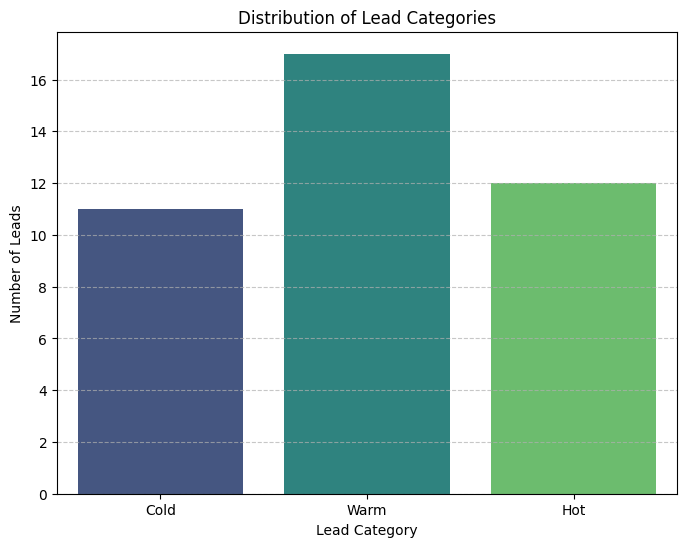

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.countplot(x='Lead Category', data=df, palette='viridis', order=['Cold', 'Warm', 'Hot'])
plt.title('Distribution of Lead Categories')
plt.xlabel('Lead Category')
plt.ylabel('Number of Leads')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Section 8: Conclusion

(Summary and insights can be added here.)

## Section 9: (Optional) Machine Learning Classifier

(Machine learning model development can be added here.)

## Section 9: Machine Learning Classifier

While a rule-based system provides a clear and interpretable way to score leads, machine learning can offer a more data-driven approach, potentially capturing complex relationships within the data to predict lead conversion. Here, we'll build a simple classification model to predict whether a lead will convert (`Converted` column).

### Data Preparation for ML

First, we need to prepare our data. This involves:
1.  **Feature Selection**: Identifying relevant features.
2.  **One-Hot Encoding**: Converting categorical features into numerical format suitable for machine learning algorithms.
3.  **Splitting Data**: Dividing the dataset into training and testing sets.

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define features (X) and target (y)
X = df[['Industry', 'Budget', 'Urgency', 'Company_Size', 'Employees']]
y = df['Converted']

# Identify categorical and numerical features
categorical_features = ['Industry', 'Budget', 'Urgency', 'Company_Size']
numerical_features = ['Employees']

# Create a column transformer for one-hot encoding categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Data preparation complete. X_train shape:", X_train.shape, "y_train shape:", y_train.shape)

Data preparation complete. X_train shape: (28, 5) y_train shape: (28,)


### Model Training

We'll use a Logistic Regression classifier, a simple yet effective model for binary classification, to predict lead conversion.

In [35]:
from sklearn.linear_model import LogisticRegression

# Create a pipeline that first preprocesses the data and then applies the classifier
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### Model Evaluation

Evaluate the trained model using metrics like accuracy, precision, recall, and F1-score on the test set.

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print(f"Model Precision: {precision:.4f}")
print(f"Model Recall: {recall:.4f}")
print(f"Model F1-Score: {f1:.4f}")
print("\nConfusion Matrix:\n", conf_matrix)

Model Accuracy: 0.5833
Model Precision: 0.5000
Model Recall: 0.6000
Model F1-Score: 0.5455

Confusion Matrix:
 [[4 3]
 [2 3]]
